# Introduction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Understanding structure, data types, and missing values
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


# Data Cleaning

In [4]:
# Check missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [5]:
# Drop Postal Code column
df.drop(columns=['Postal Code'], inplace=True)

# Exploratory Data Analysis

**1. Total Sales**

In [6]:
df['Sales'].sum()

np.float64(2261536.7827)

**2. Sales by Region**

In [7]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

**3. Sales by Category**

In [8]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

# Insights

**1. Total Sales**

- 2,261,536.78

The dataset generated over **2.26 million in total sales**, indicating a large-scale 
retail operation with significant revenue volume.

**2. Sales by Region**
- West: 710k (highest)
- East: 669k
- Central: 492k
- South: 389k (lowest)

The **West region** is the **top-performing market**, contributing the highest sales, 
while the **South region underperforms**, suggesting potential opportunities for growth 
or improvement.

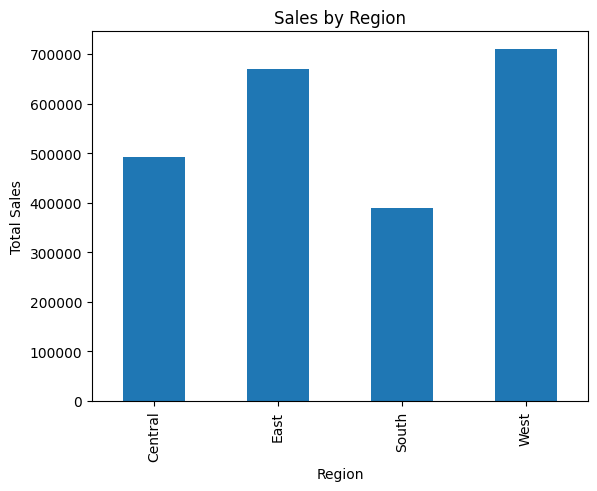

In [9]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

**3. Sales by Category**
- Technology: 827k (highest)
- Furniture: 728k
- Office Supplies: 705k

**Technology products drive the most revenue**, making them the most valuable category, 
while Furniture and Office Supplies perform slightly lower but still contribute significantly.

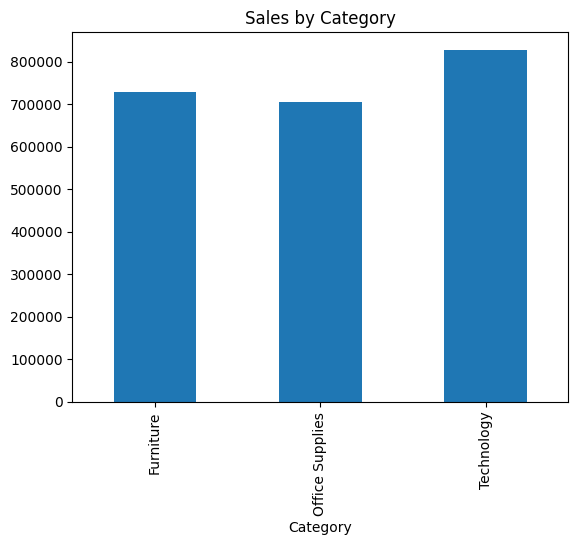

In [10]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

**4. Sales over time**

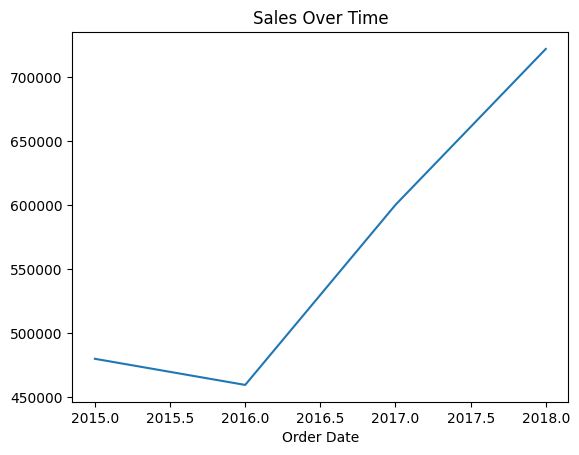

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

df.groupby(df['Order Date'].dt.year)['Sales'].sum().plot(kind='line')
plt.title("Sales Over Time")
plt.show()

# Advanced EDA

**1. Top 10 Products**

In [18]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

**2. Worst 10 Products**

In [13]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=True).head(10)

Product Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Name: Sales, dtype: float64

**3. Monthly Sales Trend**

<Axes: xlabel='Order Date'>

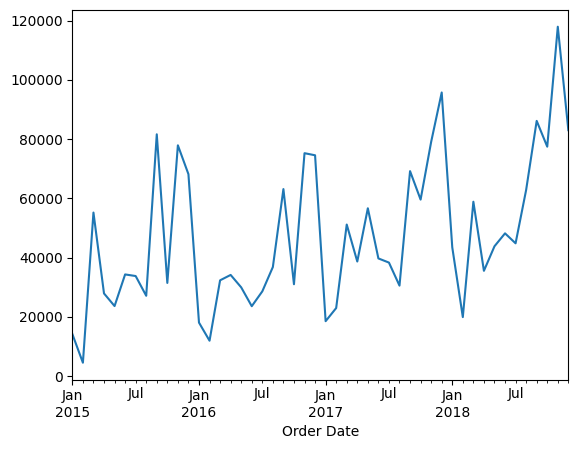

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().plot()

**4. Segment Analysis**

<Axes: xlabel='Segment'>

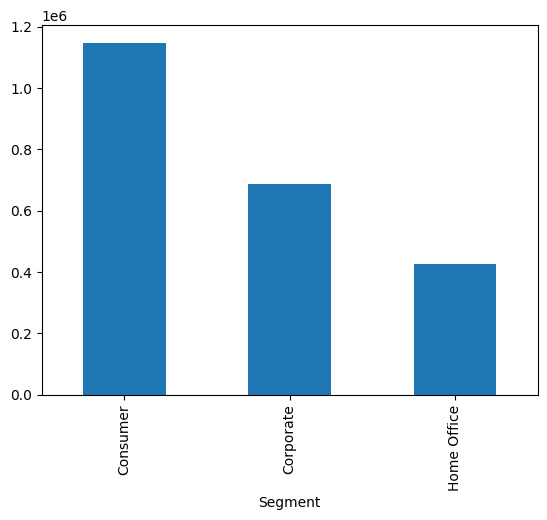

In [16]:
df.groupby('Segment')['Sales'].sum().plot(kind='bar')

# Key findings

- The dataset generated over **2.26 million in total sales**, indicating strong overall business performance.
- The **West region** is the top-performing region, while the **South region** shows the lowest sales,
suggesting potential areas for improvement.
- **Technology products** are the highest revenue-generating category, making them the most valuable
segment of the business.
- A small number of **top-performing products contribute significantly to total revenue**, while several
products show very low sales.
- Sales trends over time indicate **growth patterns with possible fluctuations**, suggesting seasonal
or demand-based variation.
- The **Consumer segment contributes the highest share of sales**, highlighting it as the primary target market.